# AI Report Maker — LangGraph Pipeline 시각화

이 노트북은 `server/agents/orchestrator_agent.py`의 StateGraph 파이프라인을 노드·엣지 형태로 시각화합니다.

- **Cell 1** : 전체 StateGraph (노드 + 일반 엣지 + 조건부 엣지)
- **Cell 2** : render 노드별 처리 전략 매트릭스
- **Cell 3** : AgentState 필드 수명주기 테이블
- **Cell 4** : LangGraph 네이티브 시각화 (`pip install langgraph` 필요)

In [1]:
# ── 의존성 확인 ──────────────────────────────────────────────────────────────
import subprocess, sys

for pkg in ['networkx', 'matplotlib']:
    try:
        __import__(pkg)
    except ImportError:
        print(f'[설치 중] {pkg}')
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg], check=True)

print('준비 완료')

준비 완료


C:\Users\osy\AppData\Local\Temp\ipykernel_13560\682949254.py:129: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\682949254.py:129: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\682949254.py:129: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\682949254.py:129: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\682949254.py:129: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\682949254.py:129: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaV

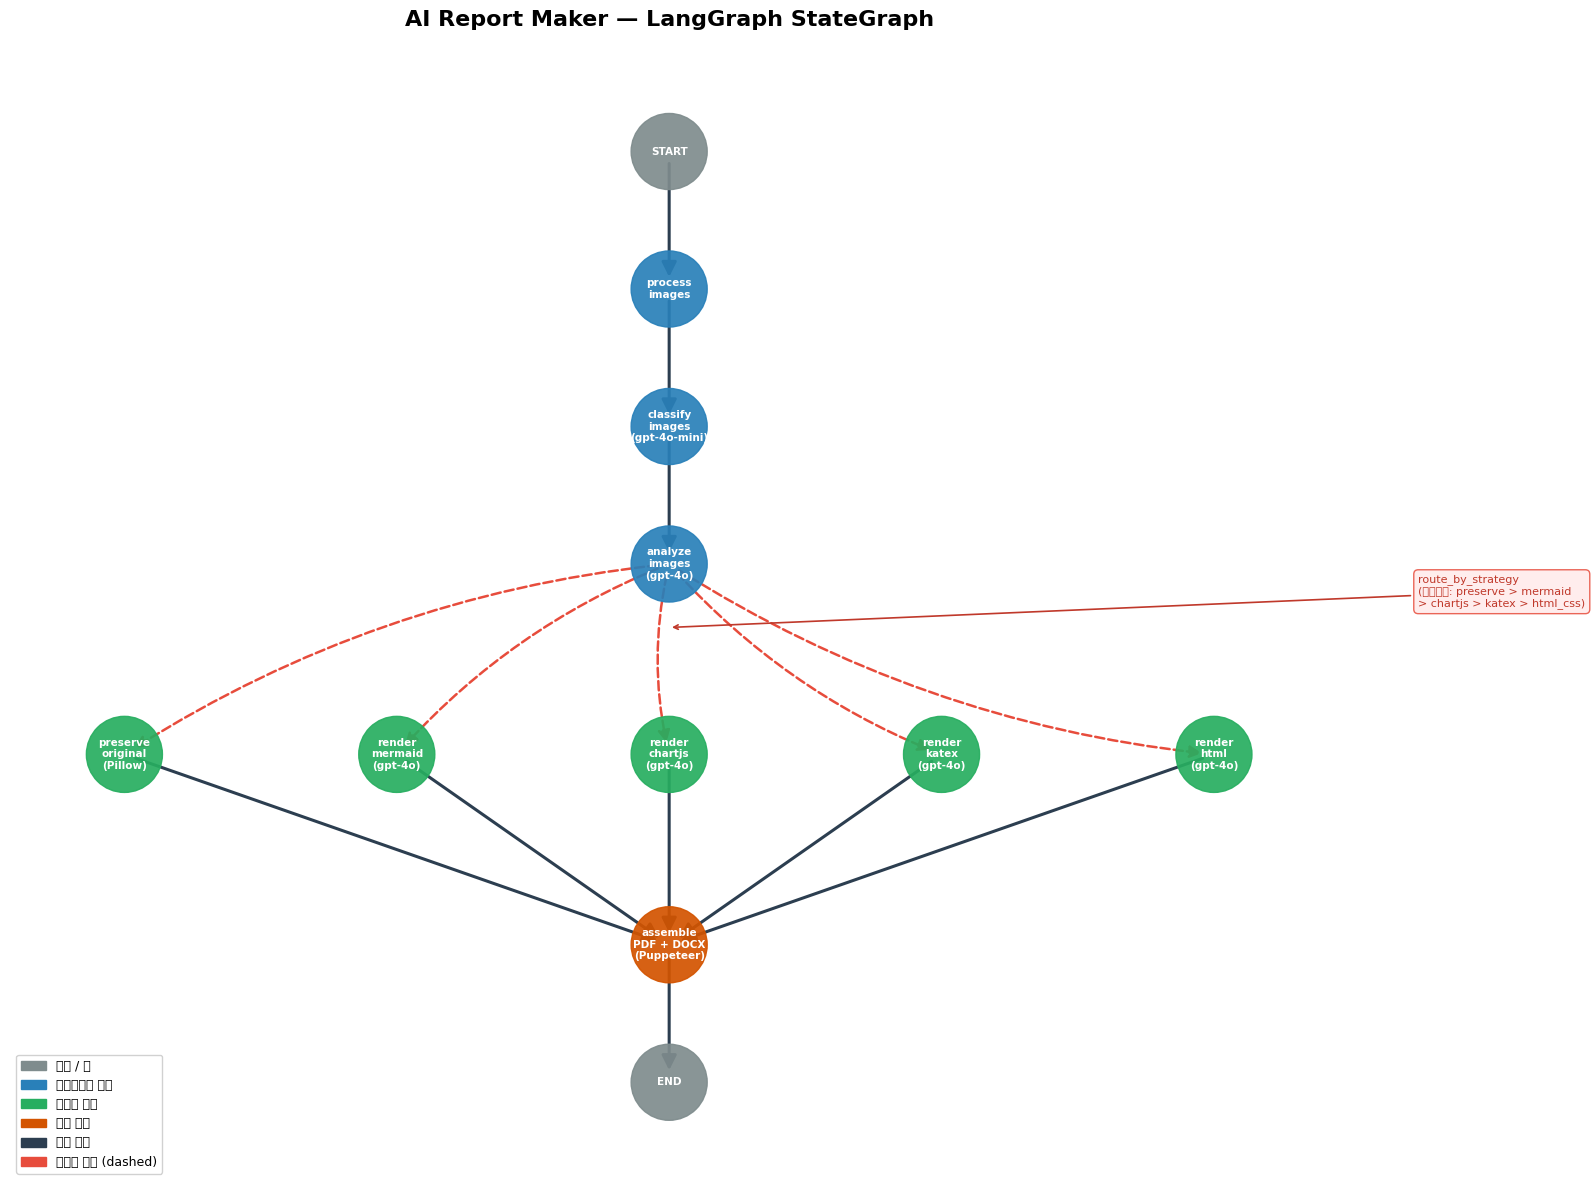

In [2]:
# ── Cell 1: 전체 StateGraph ──────────────────────────────────────────────────
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 노드 정의 ─────────────────────────────────────────────────────────────────
NODES = [
    ('__start__',          'special'),
    ('process_images',     'pipeline'),
    ('classify_images',    'pipeline'),
    ('analyze_images',     'pipeline'),
    ('preserve_original',  'render'),
    ('render_mermaid',     'render'),
    ('render_chartjs',     'render'),
    ('render_katex',       'render'),
    ('render_html',        'render'),
    ('assemble_pdf',       'output'),
    ('__end__',            'special'),
]

# ── 엣지 정의 ─────────────────────────────────────────────────────────────────
EDGES_NORMAL = [
    ('__start__',         'process_images'),
    ('process_images',    'classify_images'),
    ('classify_images',   'analyze_images'),
    ('preserve_original', 'assemble_pdf'),
    ('render_mermaid',    'assemble_pdf'),
    ('render_chartjs',    'assemble_pdf'),
    ('render_katex',      'assemble_pdf'),
    ('render_html',       'assemble_pdf'),
    ('assemble_pdf',      '__end__'),
]
EDGES_COND = [
    ('analyze_images', 'preserve_original'),
    ('analyze_images', 'render_mermaid'),
    ('analyze_images', 'render_chartjs'),
    ('analyze_images', 'render_katex'),
    ('analyze_images', 'render_html'),
]

# ── 그래프 생성 ───────────────────────────────────────────────────────────────
G = nx.DiGraph()
for name, ntype in NODES:
    G.add_node(name, ntype=ntype)
for u, v in EDGES_NORMAL + EDGES_COND:
    G.add_edge(u, v)

# ── 레이아웃 (수동 배치) ───────────────────────────────────────────────────────
POS = {
    '__start__':          (4.0, 10.5),
    'process_images':     (4.0,  9.2),
    'classify_images':    (4.0,  7.9),
    'analyze_images':     (4.0,  6.6),
    'preserve_original':  (0.0,  4.8),
    'render_mermaid':     (2.0,  4.8),
    'render_chartjs':     (4.0,  4.8),
    'render_katex':       (6.0,  4.8),
    'render_html':        (8.0,  4.8),
    'assemble_pdf':       (4.0,  3.0),
    '__end__':            (4.0,  1.7),
}

# ── 색상 ──────────────────────────────────────────────────────────────────────
COLOR = {
    'special':  '#7f8c8d',
    'pipeline': '#2980b9',
    'render':   '#27ae60',
    'output':   '#d35400',
}
node_colors = [COLOR[G.nodes[n]['ntype']] for n in G.nodes]

# ── 노드 라벨 (줄바꿈) ──────────────────────────────────────────────────────────
LABELS = {
    '__start__':          'START',
    'process_images':     'process\nimages',
    'classify_images':    'classify\nimages\n(gpt-4o-mini)',
    'analyze_images':     'analyze\nimages\n(gpt-4o)',
    'preserve_original':  'preserve\noriginal\n(Pillow)',
    'render_mermaid':     'render\nmermaid\n(gpt-4o)',
    'render_chartjs':     'render\nchartjs\n(gpt-4o)',
    'render_katex':       'render\nkatex\n(gpt-4o)',
    'render_html':        'render\nhtml\n(gpt-4o)',
    'assemble_pdf':       'assemble\nPDF + DOCX\n(Puppeteer)',
    '__end__':            'END',
}

# ── 그리기 ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_nodes(G, POS, node_color=node_colors,
                       node_size=3000, ax=ax, alpha=0.92)

nx.draw_networkx_edges(G, POS, edgelist=EDGES_NORMAL, ax=ax,
                       arrows=True, arrowsize=22,
                       edge_color='#2c3e50', width=2.2)

nx.draw_networkx_edges(G, POS, edgelist=EDGES_COND, ax=ax,
                       arrows=True, arrowsize=18,
                       edge_color='#e74c3c', width=1.8,
                       style='dashed',
                       connectionstyle='arc3,rad=0.12')

nx.draw_networkx_labels(G, POS, labels=LABELS, ax=ax,
                        font_size=7.5, font_color='white', font_weight='bold')

# ── route_by_strategy 우선순위 주석 ───────────────────────────────────────────
ax.annotate(
    'route_by_strategy\n(우선순위: preserve > mermaid\n> chartjs > katex > html_css)',
    xy=(4.0, 6.0), xytext=(9.5, 6.2),
    fontsize=8, color='#c0392b',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.4', fc='#ffeaea', ec='#e74c3c', alpha=0.85)
)

# ── 범례 ──────────────────────────────────────────────────────────────────────
legend = [
    mpatches.Patch(color='#7f8c8d', label='시작 / 끝'),
    mpatches.Patch(color='#2980b9', label='파이프라인 노드'),
    mpatches.Patch(color='#27ae60', label='렌더링 노드'),
    mpatches.Patch(color='#d35400', label='출력 노드'),
    mpatches.Patch(color='#2c3e50', label='순차 엣지'),
    mpatches.Patch(color='#e74c3c', label='조건부 엣지 (dashed)'),
]
ax.legend(handles=legend, loc='lower left', fontsize=9,
          framealpha=0.9, edgecolor='#ccc')

ax.set_title('AI Report Maker — LangGraph StateGraph', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

C:\Users\osy\AppData\Local\Temp\ipykernel_13560\2652976126.py:69: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\2652976126.py:69: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\2652976126.py:69: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\2652976126.py:69: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\2652976126.py:69: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\2652976126.py:69: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) D

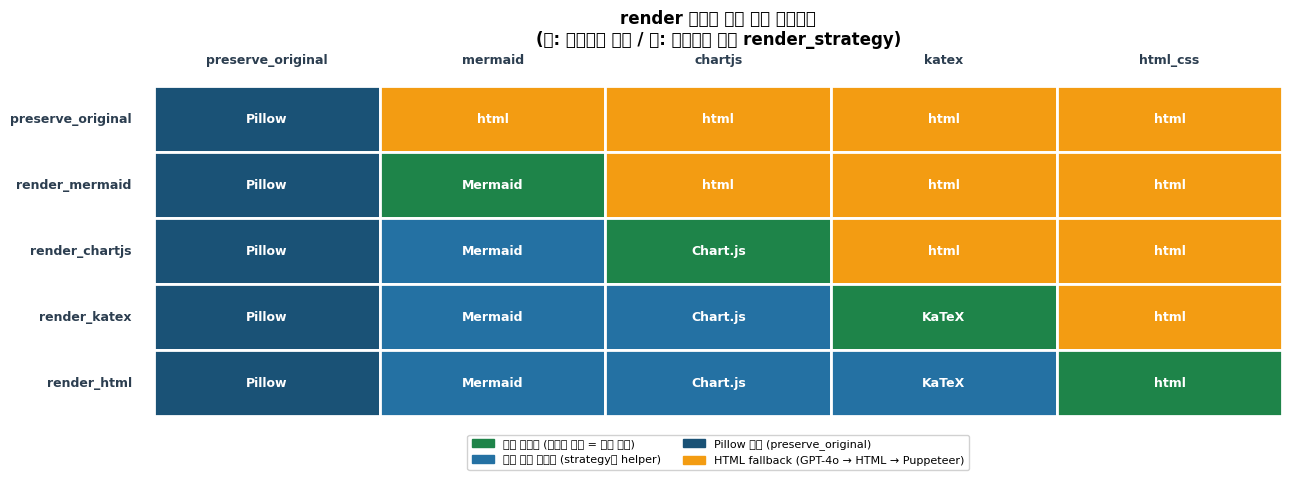

In [3]:
# ── Cell 2: render 노드별 처리 전략 매트릭스 ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 행: 라우팅된 노드 / 열: 이미지의 실제 render_strategy
# 값: 0=html fallback, 1=pillow only, 2=해당 전문 렌더러, 3=다른 전문 렌더러

ROWS = ['preserve_original', 'render_mermaid', 'render_chartjs', 'render_katex', 'render_html']
COLS = ['preserve_original', 'mermaid', 'chartjs', 'katex', 'html_css']

# 각 셀: (숫자코드, 표시텍스트)
# 1=Pillow(green-dark), 2=전문(blue), 3=다른전문(cyan), 0=html fallback(orange)
TABLE = [
#  pres_orig  mermaid   chartjs   katex   html_css
  [(1,'Pillow'),(0,'html'),(0,'html'),(0,'html'),(0,'html')],    # preserve_original 노드
  [(1,'Pillow'),(2,'Mermaid'),(0,'html'),(0,'html'),(0,'html')], # render_mermaid 노드
  [(1,'Pillow'),(3,'Mermaid'),(2,'Chart.js'),(0,'html'),(0,'html')], # render_chartjs 노드
  [(1,'Pillow'),(3,'Mermaid'),(3,'Chart.js'),(2,'KaTeX'),(0,'html')], # render_katex 노드
  [(1,'Pillow'),(3,'Mermaid'),(3,'Chart.js'),(3,'KaTeX'),(2,'html')], # render_html 노드
]

CODE_COLOR = {
    0: '#f39c12',  # html fallback (주황)
    1: '#1a5276',  # Pillow 전용 (짙은 파랑)
    2: '#1e8449',  # 전문 렌더러 (진초록)
    3: '#2471a3',  # 다른 전문 렌더러 (파랑)
}

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, len(COLS))
ax.set_ylim(0, len(ROWS))
ax.axis('off')

cell_w, cell_h = 1.0, 1.0
for r_idx, row in enumerate(TABLE):
    for c_idx, (code, label) in enumerate(row):
        y = len(ROWS) - r_idx - 1
        rect = plt.Rectangle((c_idx, y), cell_w, cell_h,
                               facecolor=CODE_COLOR[code], edgecolor='white', linewidth=2)
        ax.add_patch(rect)
        ax.text(c_idx + 0.5, y + 0.5, label,
                ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')

# 열 헤더
for c_idx, col in enumerate(COLS):
    ax.text(c_idx + 0.5, len(ROWS) + 0.3, col,
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50')

# 행 헤더
for r_idx, row_name in enumerate(ROWS):
    y = len(ROWS) - r_idx - 1
    ax.text(-0.1, y + 0.5, row_name,
            ha='right', va='center', fontsize=9, fontweight='bold', color='#2c3e50')

# 범례
legend_items = [
    mpatches.Patch(color='#1e8449', label='전문 렌더러 (이미지 전략 = 노드 전략)'),
    mpatches.Patch(color='#2471a3', label='다른 전문 렌더러 (strategy별 helper)'),
    mpatches.Patch(color='#1a5276', label='Pillow 정제 (preserve_original)'),
    mpatches.Patch(color='#f39c12', label='HTML fallback (GPT-4o → HTML → Puppeteer)'),
]
ax.legend(handles=legend_items, loc='lower center',
          bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8, framealpha=0.9)

ax.set_title('render 노드별 처리 전략 매트릭스\n(행: 라우팅된 노드 / 열: 이미지의 실제 render_strategy)',
             fontsize=12, fontweight='bold', pad=30)
plt.tight_layout()
plt.show()

C:\Users\osy\AppData\Local\Temp\ipykernel_13560\3367708746.py:74: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\3367708746.py:74: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\3367708746.py:74: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\3367708746.py:74: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\3367708746.py:74: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\osy\AppData\Local\Temp\ipykernel_13560\3367708746.py:74: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) De

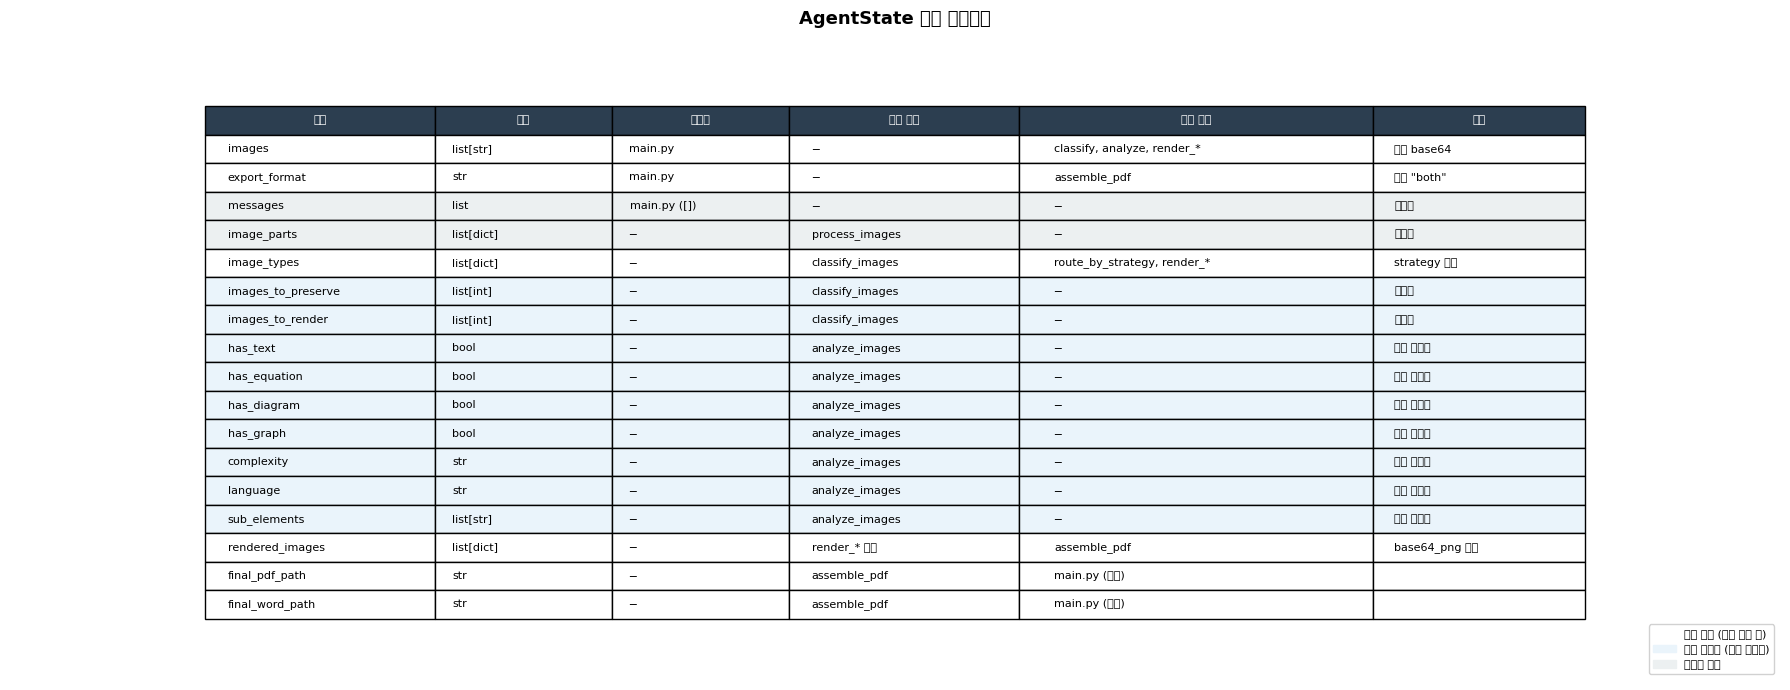

In [4]:
# ── Cell 3: AgentState 필드 수명주기 테이블 ──────────────────────────────────
import matplotlib.pyplot as plt

FIELDS = [
    # (필드명, 타입, 초기화, 기록 노드, 읽는 노드, 비고)
    ('images',             'list[str]',   'main.py',          '─',                 'classify, analyze, render_*',   '원본 base64'),
    ('export_format',      'str',         'main.py',          '─',                 'assemble_pdf',                  '항상 "both"'),
    ('messages',           'list',        'main.py ([])',      '─',                 '─',                             '미사용'),
    ('image_parts',        'list[dict]',  '─',                'process_images',    '─',                             '미사용'),
    ('image_types',        'list[dict]',  '─',                'classify_images',   'route_by_strategy, render_*',   'strategy 포함'),
    ('images_to_preserve', 'list[int]',   '─',                'classify_images',   '─',                             '참고용'),
    ('images_to_render',   'list[int]',   '─',                'classify_images',   '─',                             '참고용'),
    ('has_text',           'bool',        '─',                'analyze_images',    '─',                             '향후 확장용'),
    ('has_equation',       'bool',        '─',                'analyze_images',    '─',                             '향후 확장용'),
    ('has_diagram',        'bool',        '─',                'analyze_images',    '─',                             '향후 확장용'),
    ('has_graph',          'bool',        '─',                'analyze_images',    '─',                             '향후 확장용'),
    ('complexity',         'str',         '─',                'analyze_images',    '─',                             '향후 확장용'),
    ('language',           'str',         '─',                'analyze_images',    '─',                             '향후 확장용'),
    ('sub_elements',       'list[str]',   '─',                'analyze_images',    '─',                             '향후 확장용'),
    ('rendered_images',    'list[dict]',  '─',                'render_* 노드',     'assemble_pdf',                  'base64_png 포함'),
    ('final_pdf_path',     'str',         '─',                'assemble_pdf',      'main.py (응답)',                ''),
    ('final_word_path',    'str',         '─',                'assemble_pdf',      'main.py (응답)',                ''),
]

COL_HEADERS = ['필드', '타입', '초기화', '기록 노드', '읽는 노드', '비고']

# 색상: 미사용=회색, 향후=연한파랑, 핵심=흰색
def row_color(field):
    if field in ('messages', 'image_parts'):
        return '#ecf0f1'
    if field in ('has_text','has_equation','has_diagram','has_graph',
                 'complexity','language','sub_elements',
                 'images_to_preserve','images_to_render'):
        return '#eaf4fb'
    return 'white'

fig, ax = plt.subplots(figsize=(18, 7))
ax.axis('off')

table_data = [[f, t, init, write, read, note] for f, t, init, write, read, note in FIELDS]
row_colors = [[row_color(f)] * 6 for f, *_ in FIELDS]

tbl = ax.table(
    cellText=table_data,
    colLabels=COL_HEADERS,
    cellLoc='left',
    loc='center',
    cellColours=row_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.45)

# 헤더 색상
for j in range(len(COL_HEADERS)):
    tbl[(0, j)].set_facecolor('#2c3e50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# 컬럼 폭 조정
col_widths = [0.13, 0.10, 0.10, 0.13, 0.20, 0.12]
for j, w in enumerate(col_widths):
    for i in range(len(FIELDS) + 1):
        tbl[(i, j)].set_width(w)

ax.set_title('AgentState 필드 수명주기', fontsize=13, fontweight='bold', pad=15)

# 범례
legend = [
    mpatches.Patch(color='white',   label='핵심 필드 (현재 사용 중)'),
    mpatches.Patch(color='#eaf4fb', label='향후 확장용 (현재 미사용)'),
    mpatches.Patch(color='#ecf0f1', label='미사용 필드'),
]
ax.legend(handles=legend, loc='lower right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

In [5]:
!pip install -r requirements.txt

In [6]:
!pip install grandalf

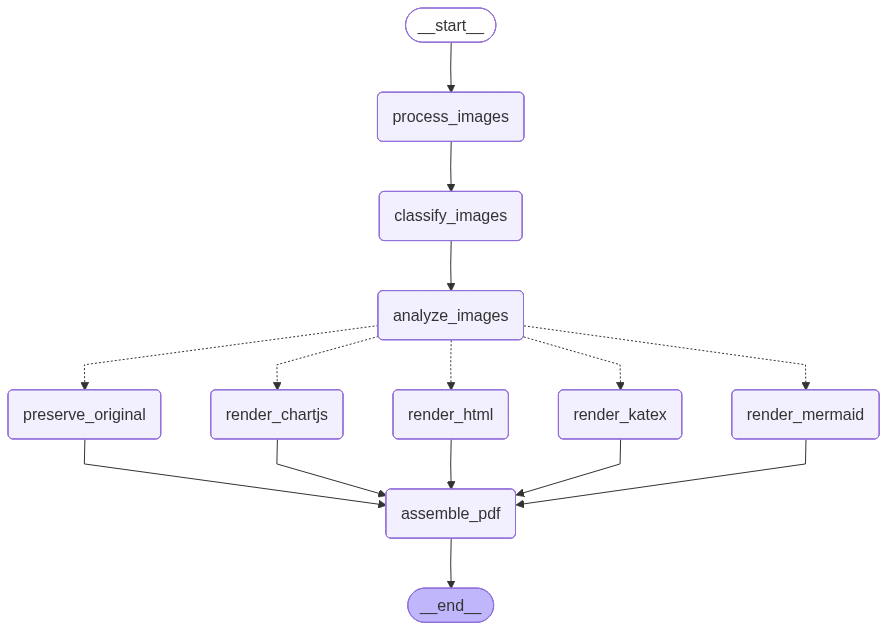

In [9]:
# ── Cell 4: LangGraph 네이티브 시각화 ────────────────────────────────────────
# langgraph + 관련 패키지가 설치된 환경에서만 동작합니다.
# 실행 디렉터리: ai_report_maker/ (server/ 가 상위)
import sys, os

SERVER_DIR = os.path.abspath(os.path.join(os.getcwd(), 'server'))
if SERVER_DIR not in sys.path:
    sys.path.insert(0, SERVER_DIR)

try:
    from agents.orchestrator_agent import graph

    # ── PNG 출력 (pygraphviz 또는 Mermaid 필요) ────────────────────────────────
    try:
        from IPython.display import Image, display
        png_bytes = graph.get_graph().draw_mermaid_png()
        display(Image(png_bytes))
    except Exception as e:
        print(f'[PNG 생략] draw_mermaid_png 불가: {e}')
        print('→ pip install pygraphviz  또는  playwright install 후 재시도')

except ImportError as e:
    print(f'[건너뜀] 패키지 미설치: {e}')
    print('→ pip install -r server/../requirements.txt 후 재시도')
except Exception as e:
    print(f'[오류] {e}')